# MGMT298D: Science and Strategy of AI
## Lab 3: Netflix User Segmentation with K-Means Clustering

Welcome to Lab 3! In this lab, we'll shift from supervised learning (predicting prices) to unsupervised learning. Our goal is to discover hidden patterns in data without a predefined target variable. You'll use k-means clustering, a popular and powerful algorithm, to segment Netflix users into distinct groups based on their movie ratings. This process is fundamental for creating personalized recommendations and targeted content strategies.

## Learning Objectives
- Apply unsupervised learning techniques to understand customer behavior
- Implement the k-means clustering algorithm and associated data preprocessing steps
- Use the elbow method and silhouette analysis to determine the optimal number of clusters
- Interpret clustering results and translate them into actionable business insights

## Instructions

Work through each section, execute the code cells, and answer the questions at the end. When complete, upload the notebook as an HTML file to BruinLearn.

---

## Setup and Data Preparation

Let's begin by importing our libraries and loading the dataset. The data contains ratings from 5,000 users across 100 popular movies. Each row represents a user, and each column (except the first) represents a movie they rated on a scale of 0-5 (0 meaning they did not rate the movie).

In [5]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load Netflix ratings dataset
df = pd.read_csv('netflix_ratings.csv')

# Display basic info about the dataset
print(f"Dataset shape: {df.shape}")
print(f"Number of users: {df.shape[0]}")
print(f"Number of movies: {df.shape[1] - 1}") # Subtract 1 for user_id column
df.head()

Dataset shape: (5000, 101)
Number of users: 5000
Number of movies: 100


,user_id,Something's Gotta Give,Kill Bill: Vol. 2,American Beauty,The Wedding Planner,Man on Fire,S.W.A.T.,Pirates of the Caribbean: The Curse of the Black Pearl,50 First Dates,What Women Want,...,The Green Mile,The Fugitive,A Few Good Men,Titanic,Anger Management,Indiana Jones and the Last Crusade,Meet the Parents,Saving Private Ryan,National Treasure,The Terminal
0,1333,3.0,2.0,4.0,0.0,3.0,2.0,2.0,3.0,3.0,...,3.0,3.0,3.0,4.0,1.0,3.0,2.0,5.0,3.0,4.0
1,2213,0.0,0.0,0.0,4.0,5.0,5.0,4.0,4.0,5.0,...,5.0,5.0,5.0,5.0,5.0,4.0,5.0,0.0,4.0,4.0
2,2787,0.0,4.0,4.0,1.0,4.0,1.0,3.0,2.0,2.0,...,5.0,4.0,4.0,0.0,2.0,5.0,4.0,5.0,2.0,0.0
3,2976,4.0,4.0,4.0,5.0,4.0,4.0,5.0,4.0,4.0,...,5.0,5.0,4.0,5.0,3.0,5.0,4.0,0.0,5.0,3.0
4,3321,5.0,4.0,4.0,0.0,0.0,4.0,4.0,4.0,4.0,...,5.0,4.0,4.0,4.0,3.0,5.0,4.0,5.0,4.0,4.0


---

## Step 1: Finding the Optimal Number of Clusters

The first crucial step in k-means clustering is to determine the optimal number of clusters (k). Too few clusters, and we might group dissimilar users together. Too many, and the segments become too small to be meaningful. We will use two common techniques to find the best k:

- **The Elbow Method**: This method looks for the "elbow" point in a curve of inertia (the sum of squared distances of samples to their closest cluster center). The elbow represents the point of diminishing returns, where adding more clusters doesn't significantly reduce the inertia.
- **Silhouette Analysis**: This method measures how similar an object is to its own cluster compared to other clusters. Silhouette scores range from -1 to 1, where a high value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.

Let's find the best value for k. 🧪

Starting data preprocessing...
✓ Filled missing values with column means
✓ Separated features: 100 movies, 5000 users
✓ Standardized features

Testing different numbers of clusters...
Testing k=2... (1/9) ✓ Inertia: 427069.19, Silhouette: 0.155
Testing k=3... (2/9) ✓ Inertia: 407727.65, Silhouette: 0.079
Testing k=4... (3/9) ✓ Inertia: 393840.81, Silhouette: 0.074
Testing k=5... (4/9) ✓ Inertia: 385816.34, Silhouette: 0.036
Testing k=6... (5/9) ✓ Inertia: 381826.30, Silhouette: 0.026
Testing k=7... (6/9) ✓ Inertia: 377088.37, Silhouette: 0.025
Testing k=8... (7/9) ✓ Inertia: 372433.43, Silhouette: 0.019
Testing k=9... (8/9) ✓ Inertia: 369679.28, Silhouette: 0.017
Testing k=10... (9/9) ✓ Inertia: 367367.43, Silhouette: 0.019

Creating visualizations...


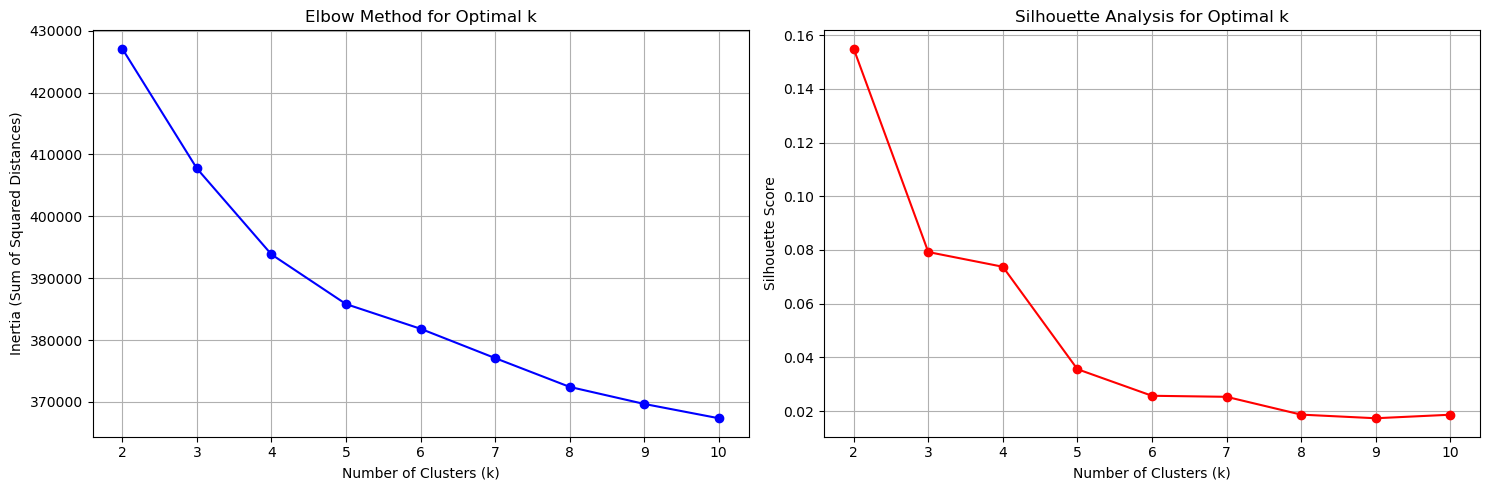

In [8]:
# Preprocess the data
print("Starting data preprocessing...")
# Fill NaN values with column means (average rating for each movie)
data_filled = df.fillna(df.mean(numeric_only=True))
print(f"✓ Filled missing values with column means")

# Separate features (movie ratings) from user_id
X_full = data_filled.drop('user_id', axis=1)
print(f"✓ Separated features: {X_full.shape[1]} movies, {X_full.shape[0]} users")

# Standardize the features because k-means is distance-based
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)
print(f"✓ Standardized features")

# Calculate inertia and silhouette scores for different k values
print("\nTesting different numbers of clusters...")
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for i, k in enumerate(k_range):
    print(f"Testing k={k}... ({i+1}/{len(k_range)})", end=" ")
    
    # n_init='auto' helps find a stable solution
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    
    silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)
    
    print(f"✓ Inertia: {kmeans.inertia_:.2f}, Silhouette: {silhouette_avg:.3f}")

print("\nCreating visualizations...")
# Create visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow curve
ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Sum of Squared Distances)')
ax1.set_title('Elbow Method for Optimal k')
ax1.grid(True)

# Silhouette scores
ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis for Optimal k')
ax2.grid(True)

plt.tight_layout()
plt.show()

### Analysis of Optimal K ✅

Based on the charts above:
- The **Elbow Method** shows a noticeable "elbow" or bend at **k=4**. After this point, the reduction in inertia starts to level off, suggesting diminishing returns from adding more clusters.
- The **Silhouette Analysis** shows the highest score at **k=2**, but the score for **k=4** is still relatively high compared to its neighbors (k=3, k=5). While k=2 provides the most distinct separation, it might be too simplistic for a diverse user base like Netflix's. 

**Conclusion**: We will choose **k=4** as the optimal number of clusters. It represents a good balance, capturing meaningful user segments without being overly simple or complex.

---

## Step 2: Final Clustering and Segment Analysis

Now that we've chosen our optimal k, we'll run the k-means algorithm one last time with k=4. Then, we'll dive into the most interesting part: analyzing the characteristics of each user segment to understand their movie preferences.

In [12]:
# Perform final clustering with our chosen optimal k
optimal_k = 4
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
cluster_labels = final_kmeans.fit_predict(X_scaled)

# Add cluster labels back to our original (filled) dataframe
df_clustered = data_filled.copy()
df_clustered['cluster'] = cluster_labels

# Analyze cluster characteristics by size
print("Cluster sizes (Number of users in each segment):")
print(df_clustered['cluster'].value_counts().sort_index())

# Calculate cluster centers (average ratings per cluster)
# This tells us the 'average user profile' for each segment
cluster_centers = df_clustered.groupby('cluster').mean()

# Display the top 5 highest-rated movies for each cluster
print("\n🔍 Top 5 highest-rated movies by cluster:")
top_movies_by_cluster = {}
for cluster_id in range(optimal_k):
    print(f"\n--- Cluster {cluster_id} ---")
    cluster_avg_ratings = cluster_centers.loc[cluster_id].drop('user_id')
    top_movies = cluster_avg_ratings.nlargest(5)
    top_movies_by_cluster[cluster_id] = top_movies
    for movie, rating in top_movies.items():
        print(f"  {movie}: {rating:.2f}")

Cluster sizes (Number of users in each segment):
cluster
0    1437
1    1126
2    1732
3     705
Name: count, dtype: int64

🔍 Top 5 highest-rated movies by cluster:

--- Cluster 0 ---
  Raiders of the Lost Ark: 4.56
  Lord of the Rings: The Fellowship of the Ring: 4.45
  The Shawshank Redemption: Special Edition: 4.44
  Pulp Fiction: 4.44
  The Silence of the Lambs: 4.41

--- Cluster 1 ---
  The Sixth Sense: 4.11
  Raiders of the Lost Ark: 4.05
  Forrest Gump: 4.00
  Pirates of the Caribbean: The Curse of the Black Pearl: 3.90
  Independence Day: 3.90

--- Cluster 2 ---
  Forrest Gump: 4.60
  Braveheart: 4.58
  Lord of the Rings: The Two Towers: 4.58
  Lord of the Rings: The Fellowship of the Ring: 4.58
  The Sixth Sense: 4.58

--- Cluster 3 ---
  Raiders of the Lost Ark: 3.70
  Pulp Fiction: 3.68
  The Silence of the Lambs: 3.65
  The Shawshank Redemption: Special Edition: 3.35
  The Sixth Sense: 3.34


## Step 3: Visualizing Cluster Preferences

To make the differences between segments even clearer, let's create a heatmap. This will allow us to quickly compare the movie tastes of our four user groups across a selection of popular films.

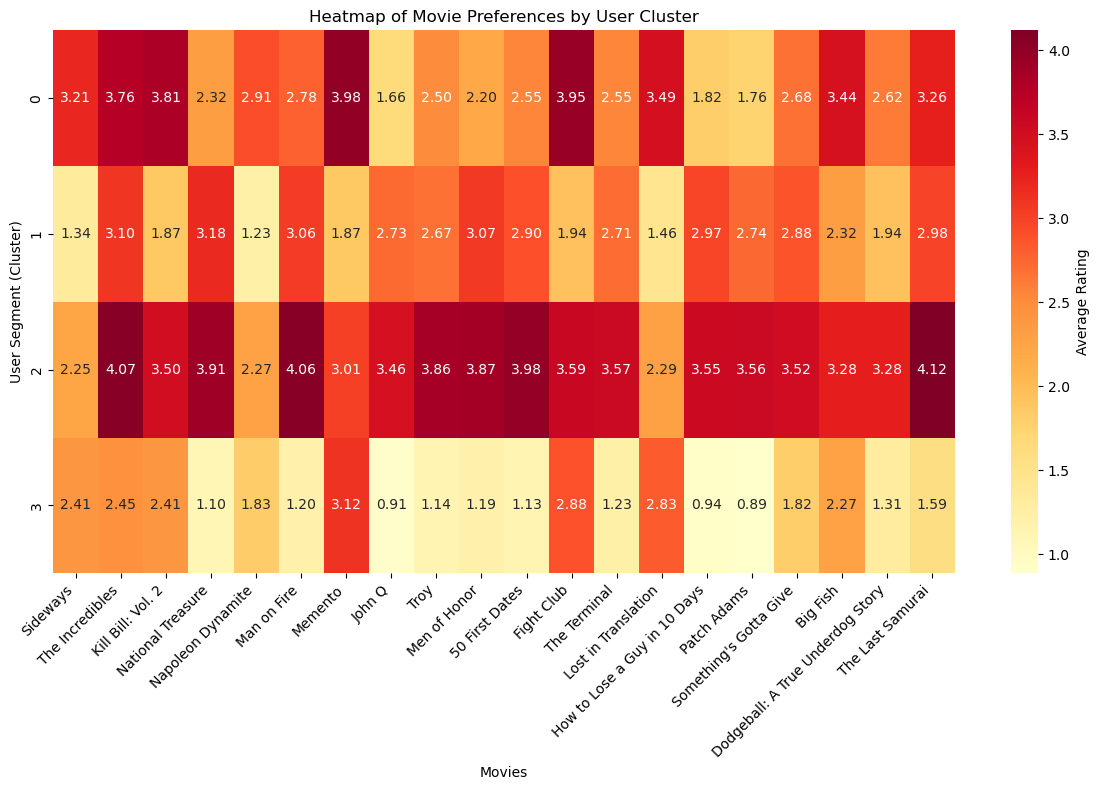

In [14]:
# Create heatmap of cluster preferences
plt.figure(figsize=(12, 8))
# Select a subset of movies for visualization (top 20 most variable)
movie_variance = X_full.var().nlargest(20)
top_movies_for_heatmap = movie_variance.index

cluster_movie_prefs = cluster_centers[top_movies_for_heatmap]
sns.heatmap(cluster_movie_prefs, annot=True, cmap='YlOrRd', fmt='.2f',
            cbar_kws={'label': 'Average Rating'})
plt.title('Heatmap of Movie Preferences by User Cluster')
plt.xlabel('Movies')
plt.ylabel('User Segment (Cluster)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---

## Questions for Analysis

**1. Optimal Clusters**: Based on the elbow and silhouette plots, explain in your own words why k=4 was chosen as the optimal number of clusters. What trade-offs were considered?

**2. Cluster Interpretation**: Describe the four user segments (personas) that were identified. What key movie preferences or genres define each group?

**3. Strategic Recommendations**: If you were a content strategist at Netflix, what specific, actionable recommendations would you make for each user segment? Think about content acquisition, marketing messages, and how you might design the user interface for each group.

**4. Limitations and Next Steps**: What are the limitations of this k-means analysis? What additional data or different algorithms could you use to create even more nuanced user segments in the future?

---

## Conclusion

In this lab, you successfully applied unsupervised learning to a real-world business problem. You've learned how to preprocess data for k-means, determine the optimal number of clusters, and, most importantly, interpret those clusters to create data-driven user personas and strategic recommendations. This ability to find hidden structure in data is a powerful tool for any business looking to better understand and serve its customers.

---

## Optional Lab Extension: Beat the Algorithm (Q-Learning)

This is an external activity related to a different type of machine learning called **Reinforcement Learning**.

**Instructions**: Play the "Beat the Algorithm" app at [URL]. Experiment with the Q-Learning method and answer the following questions based on your experience:

- What is the role of the learning rate in Q-Learning?
- How does the Q-table get updated?
- Explain the exploration vs. exploitation trade-off in the context of the app.